# Random Forest experiments
This notebook shows Evan's work on Tree based classifiers. We use Random Forest and Gradient Boosted trees to achieve a competition score of 0.7405, putting us in the top 13.1% of submissions at the time of writing.

We make use of SKLearn's pipeline along with gridsearch to tune hyperparameters. When one particular combination of features achieves a new best result, we include it in our next, more granular gridsearch to see if it holds up against a more fine-tuned hyperparameter selection. This does, however, have the potential for becoming stuck within local minima, so we need to include hyperparameters that are 'further away' as well.

### Note: There are some long grid searches in this notebook. To run our best model, use the code at the bottom.

In [1]:
#data structures
import pandas as pd
import numpy as np

#machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
#Data transformation
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler #needed with PCA
#Feature encoding
from sklearn.decomposition import PCA
from sklearn.preprocessing import TargetEncoder

from sklearn.pipeline import Pipeline

import prince #used for MCA (multiple correspondence analysis)

#metrics (performace and machine learning scores)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import time #used for seeing how long it takes to run programs

np.random.seed(42)

In [2]:
import os
print(os.getcwd())

D:\Code\Earthquake


In [3]:
train_val = pd.read_csv('data/train_values.csv') #The data values of each building
train_labels = pd.read_csv('data/train_labels.csv') #labels of data as damage severity ('damage_grade')

test_val = pd.read_csv('data/test_values.csv') #data values of contest submition (our AI would have to guess this, 
#but we won't know their 'damage_grade' for sure until DrivenData releases the answers.

#We combine the features and target label for data sampling and other transformations
df = pd.merge(train_val, train_labels, on='building_id')

## Experiments with outlier removal
This code finds all instances that have the same features but a different target outcome (damage grade). They are first removed, then the most common result of the removed duplicates (for each feature combination) are added back in
Over 28 thousand duplicates are operated on, however, removing them did not improve performance. Therefore this code is currently not used.

In [34]:
columnList = df.drop(['damage_grade', 'building_id'], axis = 1).columns.tolist()

duplicates = df[df.duplicated(subset=columnList, keep=False)]
#This code searches for the most common target outcome of the duplicates to add back in to the data
mostCommon = (
    duplicates.groupby(columnList)['damage_grade']
      .agg(lambda x: x.value_counts().idxmax())
      .reset_index()
)

mostCommon.sort_values(by=columnList).head(10)

#remove duplicates
df2 = df.drop_duplicates(subset=columnList, keep=False).copy()

#add back the most common without adding back the outliers
df2 = pd.concat([df2, mostCommon]) 
df2 = df2.fillna(0)

## Data preparation
Aside from our experiments with feature engineering and PCA/MCA, these are the main transformations on our data.
Previously we kept the RobustScaler step within our pipeline, but we needed to move it here due to needing to keep it in memory to fit on both our train/test data, as well as competition data

In [5]:
#scaler is kept outside the method it is used to
rScaler = RobustScaler().set_output(transform="pandas")

#fitScaler: whether or not the scaler should be fit to the data (used for contest submission and final testing)
def prepareData(data, fitScaler:bool):
    #define X (data features) and y (target)
    #X is all useful features
    
    
    #Default Features to drop:
    #building_id: for recordkeeping rather than data
    #The target variable: damage_grade
    if 'building_id' in data:
        data = data.drop('building_id', axis = 1)
        print('dropping building id')
    if 'damage_grade' in data:
        data = data.drop('damage_grade', axis = 1)
        print('dropping damage grade')
    
    
    #These tables are in string type and must be converted
    # categoryTables = ['geo_level_1_id','land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
    categoryTables = ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
    one_hot_tables = pd.get_dummies(data[categoryTables], dtype=int, drop_first=True)

    #remove categorical tables and add them back in as encoded tables
    X = data.drop(categoryTables, axis = 1)
    X = pd.concat([X, one_hot_tables], axis = 1)

    #scale the data
    
    if(fitScaler):
        rScaler.fit(X)
    X = rScaler.transform(X)
    return X

Finally, we perform the transformations on our data, separating test and train data, and stratifying our samples in order to account for class imbalances

In [6]:
X = prepareData(df, True)
#y is target (final column 'default payment next month')
y = df['damage_grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dropping building id
dropping damage grade


## Experiments with PCA and MCA
We attempted PCA for use with tree-based algorithms, however we never achieved increased performance with PCA. We believe that the reason is due to the low correlation of many of the features. Overfitting did not present too much of a problem, in fact most models underfit. Where necessary, regularisation was found to be more effective

In [41]:
#preparing eathquake data for PCA analysis
# scaler = StandardScaler()
# scaler = MinMaxScaler()
# X_scaled = pd.DataFrame(scaler.fit_transform(X))


# # pca = PCA(n_components=0.5)
# # X_pca = pca.fit_transform(X_scaled)

# # X = X_pca

# # mca = prince.MCA(n_components=0.7)
# mca = prince.MCA(
#         n_components=30,
#         n_iter=3,
#         copy=False,
#         check_input=False,
#         engine='sklearn',
#         random_state=42,
#         one_hot=False
#     )
# X_mca = mca.fit_transform(X_scaled)
# X = X_mca

In [13]:
#grid search pipeline


pipeline = Pipeline([
    ('classifier', RandomForestClassifier())
])

param_grid = {
    'classifier__n_estimators': [400, 500, 600],
    'classifier__max_depth': [None],
}

#This code was adapted from the documentation
gridSearch = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc_ovr', # Metric to optimize (e.g., accuracy, f1_macro, etc.)
    n_jobs=-1, # Use all available processors
    verbose = 100
)

In [14]:
gridSearch

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'classifier__max_depth': [None], 'classifier__n_estimators': [400, 500, ...]}"
,scoring,'roc_auc_ovr'
,n_jobs,-1
,refit,True
,cv,5
,verbose,100
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [15]:
#Grid search training
start_time = time.perf_counter()

gridSearch.fit(X_train, y_train)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Elapsed time: 410.3734 seconds


In [16]:
print(f"Best parameters: {gridSearch.best_params_}")
print(f"Best cross-validation score: {gridSearch.best_score_:.4f}")

# Get the best model
best_model = gridSearch.best_estimator_

Best parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 600}
Best cross-validation score: 0.8426


In [17]:
train_accuracy = best_model.score(X_train, y_train)
print(f"Train set accuracy with best model: {train_accuracy:.4f}")

Train set accuracy with best model: 0.9868


In [18]:
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")

Test set accuracy with best model: 0.7197


In [29]:
param_grid2 = {
    'classifier__n_estimators': [600, 700],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 7], #Minimum number of samples required to split an internal node. Higher values increase regularization.
}

#This code was taken from the documentation
gridSearch2 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid2,
    cv=5, # 5-fold cross-validation
    scoring='f1_macro', # Metric to optimize (e.g., accuracy, f1_macro, etc.)
    n_jobs=-1, # Use all available processors
    verbose = 1
)

In [30]:
#Grid search training
start_time = time.perf_counter()

gridSearch2.fit(X_train, y_train)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Elapsed time: 1082.2446 seconds


In [31]:
print(f"Best parameters: {gridSearch2.best_params_}")
print(f"Best cross-validation score: {gridSearch2.best_score_:.4f}")

# Get the best model
best_model = gridSearch2.best_estimator_

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 600}
Best cross-validation score: 0.6573


In [32]:
train_accuracy = best_model.score(X_train, y_train)
print(f"Train set accuracy with best model: {train_accuracy:.4f}")

Train set accuracy with best model: 0.9437


In [33]:
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")

Test set accuracy with best model: 0.7268


## Gradient boosted trees

In [32]:
gb_pipeline = Pipeline([

    # ('scaler', RobustScaler()
    ('classifier', HistGradientBoostingClassifier(early_stopping=True, random_state=42))
])

gb_param_grid = {
    # 'learning_rate': [0.01, 0.1, 0.2],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_iter': [500, 600, 700, 800],
    'classifier__max_depth': [None],
    # 'max_leaf_nodes': [15, 31, 63], #Maximum leaves per tree. This is often more effective than max_depth for tree-based models.
    # 'min_samples_leaf': [20, 50], Minimum samples required in a leaf. Increasing this helps with overfitting.
    # 'l2_regularization': [0.0, 0.1, 1.0], #Regularization strength.
    # 'max_bins': [128, 255] #Maximum number of bins for histograms. Using fewer bins can act as a regularizer
    'classifier__max_bins': [255]
}

gb_gridSearch = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc_ovr', # Metric to optimize (e.g., accuracy, f1_macro, etc.)
    n_jobs=-1, # Use all available processors
    verbose = 1
)

In [33]:
#Grid search training
start_time = time.perf_counter()

gb_gridSearch.fit(X_train, y_train)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Elapsed time: 305.3624 seconds


In [34]:
print(f"Best parameters: {gb_gridSearch.best_params_}")
print(f"Best cross-validation score: {gb_gridSearch.best_score_:.4f}")

# Get the best model
best_model = gb_gridSearch.best_estimator_

Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_bins': 255, 'classifier__max_depth': None, 'classifier__max_iter': 600}
Best cross-validation score: 0.8625


In [35]:
train_accuracy = best_model.score(X_train, y_train)
print(f"Train set accuracy with best model: {train_accuracy:.4f}")

Train set accuracy with best model: 0.7872


In [36]:
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")

Test set accuracy with best model: 0.7332


### Second iteration

In [7]:
gb_pipeline = Pipeline([
    ('classifier', HistGradientBoostingClassifier(early_stopping=False, random_state=42))
], verbose=True)

gb_param_grid = {
    # 'learning_rate': [0.01, 0.1, 0.2],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__max_iter': [600, 700, 800],
    'classifier__max_depth': [None],
    # 'max_leaf_nodes': [15, 31, 63], #Maximum leaves per tree. This is often more effective than max_depth for tree-based models.
    'classifier__min_samples_leaf': [10, 20, 25], #Minimum samples required in a leaf. Increasing this helps with overfitting.
    'classifier__l2_regularization': [0.0, 0.01, 0.1, 0.13], #Regularization strength.
    # 'max_bins': [128, 255] #Maximum number of bins for histograms. Using fewer bins can act as a regularizer
    'classifier__max_bins': [255]
}

gb_gridSearch2 = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_micro', # Metric to optimize (e.g., accuracy, f1_macro, etc.)
    n_jobs=-1, # Use all available processors
    verbose = 100
)

In [8]:
#Grid search training
start_time = time.perf_counter()

gb_gridSearch2.fit(X_train, y_train)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[Pipeline] ........ (step 1 of 1) Processing classifier, total=  19.6s
Elapsed time: 3623.6074 seconds


In [9]:
print(f"Best parameters: {gb_gridSearch2.best_params_}")
print(f"Best cross-validation score: {gb_gridSearch2.best_score_:.4f}")

# Get the best model
best_model = gb_gridSearch2.best_estimator_

Best parameters: {'classifier__l2_regularization': 0.13, 'classifier__learning_rate': 0.1, 'classifier__max_bins': 255, 'classifier__max_depth': None, 'classifier__max_iter': 800, 'classifier__min_samples_leaf': 25}
Best cross-validation score: 0.7400


In [10]:
train_accuracy = best_model.score(X_train, y_train)
print(f"Train set accuracy with best model: {train_accuracy:.4f}")

Train set accuracy with best model: 0.7975


In [11]:
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")

Test set accuracy with best model: 0.7459


In [12]:
from sklearn.metrics import f1_score
y_pred = best_model.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)

0.7458989658678844


## Retraining our best model with the full dataset


In [66]:
params = gb_gridSearch2.best_params_
#remove prefixes
params = {key.replace('classifier__', ''):value for key, value in params.items()}
print(params)
# Create and train a new model instance
submissionModel = HistGradientBoostingClassifier(**params)
submissionModel.fit(X, y)

{'l2_regularization': 0.13, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_iter': 700, 'min_samples_leaf': 20}


,loss,'log_loss'
,learning_rate,0.1
,max_iter,700
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.13
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [68]:
y_pred = best_model.predict(X_test)
# y_pred = submissionModel.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)


0.7423687189424608


In [69]:
y_pred = submissionModel.predict(X_test)
# y_pred = submissionModel.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)

0.7861706413921452


In [70]:
values, counts = np.unique(y_pred, return_counts=True)
print(values, ' ', counts)

[1 2 3]   [ 3850 33804 14467]


In [71]:
#prepare the contest submission data and feed it to our model
preparedTestData = prepareData(test_val, False)

# competitionPredictions = submissionModel.predict(preparedTestData)

dropping building id


In [72]:
competitionPredictions = best_model.predict(preparedTestData)

In [73]:
values, counts = np.unique(competitionPredictions, return_counts=True)
print(values, ' ', counts)

[1 2 3]   [ 6225 56655 23988]


In [75]:
#Code borrowed from Virginia's notebook
submission_hist_boost = pd.DataFrame({
    'building_id': test_val['building_id'],
    'damage_grade': competitionPredictions
})

submission_hist_boost.to_csv('submissions/submission_hist_boost.csv', index=False)
submission_hist_boost.head()

,building_id,damage_grade
0,300051,3
1,99355,2
2,890251,2
3,745817,1
4,421793,3


# Final submission: An even deeper grid search
(warning: this will take an hour and a half)

In [104]:
gb_param_grid = {
    # 'learning_rate': [0.01, 0.1, 0.2],
    'classifier__learning_rate': [0.08, 0.09, 0.1, 0.11, 0.12],
    'classifier__max_iter': [650, 700, 750, 800, 850, 900, 950, 1000],
    'classifier__max_depth': [None],
    # 'max_leaf_nodes': [15, 31, 63], #Maximum leaves per tree. This is often more effective than max_depth for tree-based models.
    'classifier__min_samples_leaf': [1, 19, 20, 21], #Minimum samples required in a leaf. Increasing this helps with overfitting.
    'classifier__l2_regularization': [0.123, 0.125, 0.13, 0.135, 0.14, 0.15, 0.16], #Regularization strength.
    # 'max_bins': [128, 255] #Maximum number of bins for histograms. Using fewer bins can act as a regularizer
    'classifier__max_bins': [255]
}

gb_gridSearch3 = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_micro', # Metric to optimize (e.g., accuracy, f1_macro, etc.)
    n_jobs=-1, # Use all available processors
    verbose = 100
)

In [105]:
#Grid search training
start_time = time.perf_counter()

gb_gridSearch3.fit(X_train, y_train)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[Pipeline] ........ (step 1 of 1) Processing classifier, total=  16.6s
Elapsed time: 3496.0235 seconds


In [112]:
print(f"Best parameters: {gb_gridSearch3.best_params_}")
print(f"Best cross-validation score: {gb_gridSearch2.best_score_:.4f}")

# Get the best model
best_model = gb_gridSearch3.best_estimator_

Best parameters: {'classifier__l2_regularization': 0.13, 'classifier__learning_rate': 0.1, 'classifier__max_bins': 255, 'classifier__max_depth': None, 'classifier__max_iter': 800, 'classifier__min_samples_leaf': 25}
Best cross-validation score: 0.7400


In [113]:
train_accuracy = best_model.score(X_train, y_train)
print(f"Train set accuracy with best model: {train_accuracy:.4f}")

Train set accuracy with best model: 0.7975


In [114]:
test_accuracy = best_model.score(X_test, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")

Test set accuracy with best model: 0.7459


In [115]:
from sklearn.metrics import f1_score
y_pred = best_model.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)

0.7458989658678844


## Retraining the best model with all data

In [116]:
params = gb_gridSearch3.best_params_
#remove prefixes
params = {key.replace('classifier__', ''):value for key, value in params.items()}
print(params)
#{'l2_regularization': 0.13, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_iter': 800, 'min_samples_leaf': 25}

# Create and train a new model instance on the full dataset
submissionModel = HistGradientBoostingClassifier(**params)
submissionModel.fit(X, y)

{'l2_regularization': 0.13, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_iter': 800, 'min_samples_leaf': 25}


,loss,'log_loss'
,learning_rate,0.1
,max_iter,800
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,25
,l2_regularization,0.13
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [117]:
#{'l2_regularization': 0.13, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_iter': 800, 'min_samples_leaf': 25}
y_pred = submissionModel.predict(X_test)
# y_pred = submissionModel.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)

0.78774390360891


In [118]:
competitionPredictions = best_model.predict(preparedTestData)
values, counts = np.unique(competitionPredictions, return_counts=True)
print(values, ' ', counts)

[1 2 3]   [ 6226 56656 23986]


In [119]:
#Code borrowed from Virginia's notebook
submission_hist_boost = pd.DataFrame({
    'building_id': test_val['building_id'],
    'damage_grade': competitionPredictions
})

submission_hist_boost.to_csv('submissions/submission_hist_boost2.csv', index=False)
submission_hist_boost.head()

,building_id,damage_grade
0,300051,3
1,99355,2
2,890251,2
3,745817,1
4,421793,3


This is the model that we submitted to DrivenData.org under the account 'evan2222'

# To quickly recreate our best model:

In [9]:
storedParams = {'l2_regularization': 0.13, 'learning_rate': 0.1, 'max_bins': 255, 'max_depth': None, 'max_iter': 800, 'min_samples_leaf': 25}
recreatedModel = HistGradientBoostingClassifier(**storedParams)
recreatedModel.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,800
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,25
,l2_regularization,0.13
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [10]:
y_pred = recreatedModel.predict(X_test)
# y_pred = submissionModel.predict(X_test)
score = f1_score(y_test, y_pred, average='micro')
print(score)

0.7413326682143474


## Feature importance
Histboostclassifier does not have built in feature importance due to its structure. Instead we can use permutation importance to see what features have the most impact on test results

In [12]:
from sklearn.inspection import permutation_importance

result = permutation_importance(recreatedModel, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean

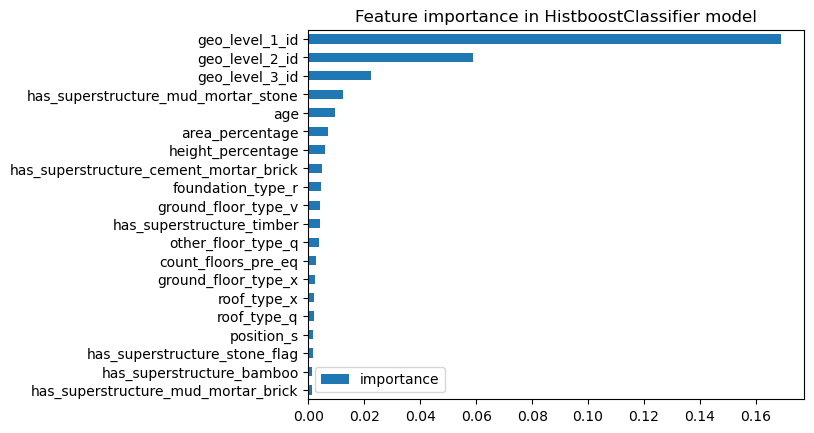

In [35]:
# featureImportances = pd.DataFrame(X.columns, importances)
featureImportances = pd.DataFrame(importances, X.columns)
featureImportances.columns = ['importance']
mostImportant = featureImportances.sort_values(by='importance', ascending=False).head(20)
import matplotlib.pyplot as plt
mostImportant.plot.barh(stacked=True)
plt.gca().invert_yaxis()
# plt.xscale('log')
plt.title('Feature importance in HistboostClassifier model')
plt.show()

The results show that geographical location (obscured by the competition runners) is the most important feature, followed by a superstructure of mortar, mud, or stone, the age of a building, the ratio of height to width, and the age of the building.